# Campaign Performance & Activation Intelligence EDA

Welcome to the interactive Exploratory Data Analysis (EDA) notebook. Unlike the `.py` script which generates a single dashboard image, this notebook allows you to run analysis cell-by-cell, inspect dataframes, and view charts inline.

### 1. Load Dependencies & Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Set dark theme for inline plots
plt.style.use('dark_background')

# Load the dataset
df = pd.read_csv('../marketing_and_product_performance.csv')

print(f"Dataset loaded with {df.shape[0]:,} rows and {df.shape[1]} columns.")
display(df.head())

Dataset loaded with 10,000 rows and 17 columns.


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


### 2. ROI Distribution
Let's look at how the Return on Investment is distributed across all campaigns.

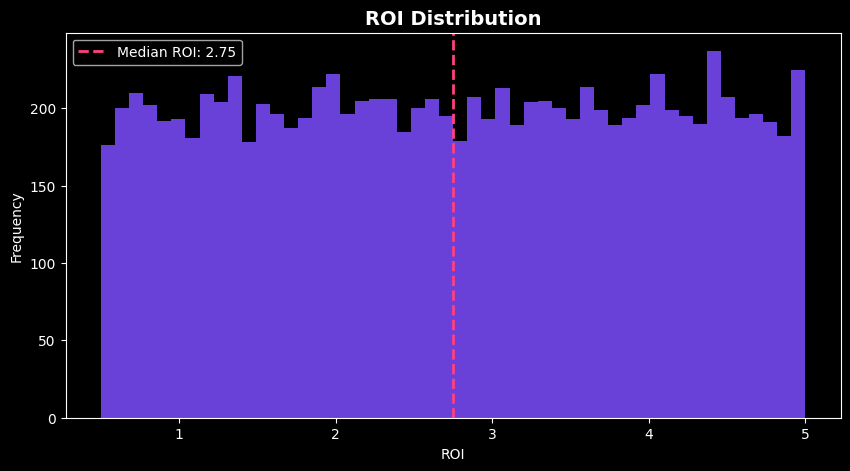

In [2]:
plt.figure(figsize=(10, 5))
roi = df["ROI"].dropna()
plt.hist(roi, bins=50, color="#7c4dff", alpha=0.85, edgecolor="none")

median_roi = roi.median()
plt.axvline(median_roi, color="#ff4081", linewidth=2, linestyle="--", label=f"Median ROI: {median_roi:.2f}")

plt.title("ROI Distribution", fontsize=14, fontweight="bold")
plt.xlabel("ROI")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### 3. Conversions by Subscription Tier
How do conversions differ between Basic, Premium, and Standard users?

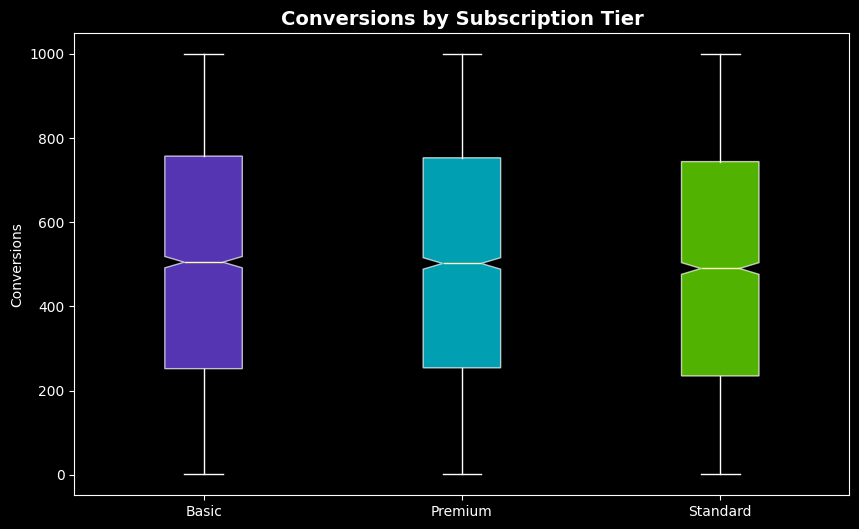

In [3]:
plt.figure(figsize=(10, 6))
tiers = sorted(df["Subscription_Tier"].dropna().unique())
tier_data = [df.loc[df["Subscription_Tier"] == t, "Conversions"].dropna() for t in tiers]

bp = plt.boxplot(tier_data, tick_labels=tiers, patch_artist=True, notch=True)

colors = ['#7c4dff', '#00e5ff', '#76ff03']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title("Conversions by Subscription Tier", fontsize=14, fontweight="bold")
plt.ylabel("Conversions")
plt.show()

### 4. Top Performing Keywords
What keywords are associated with the most campaigns?

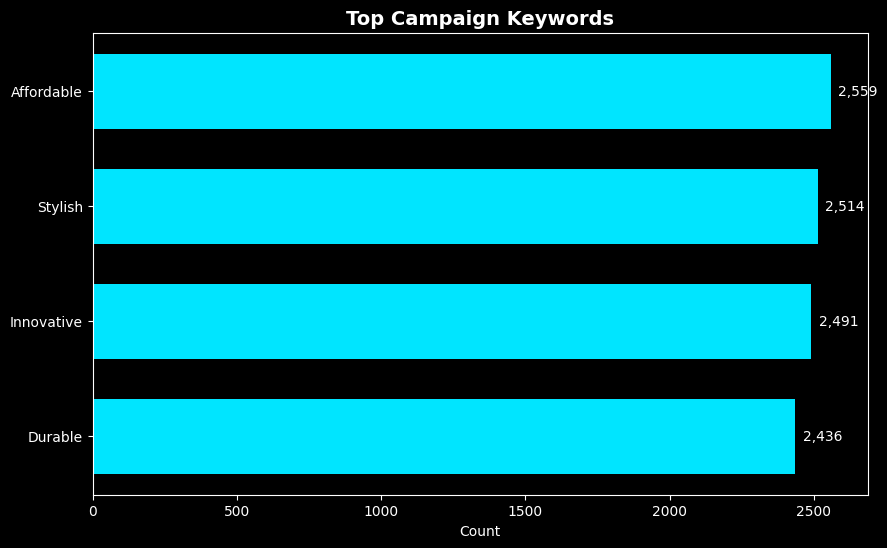

In [4]:
plt.figure(figsize=(10, 6))
kw_counts = df["Common_Keywords"].value_counts().head(10).sort_values()

bars = plt.barh(kw_counts.index, kw_counts.values, color="#00e5ff", edgecolor="none", height=0.65)

for bar, val in zip(bars, kw_counts.values):
    plt.text(val + kw_counts.max() * 0.01, bar.get_y() + bar.get_height() / 2, 
             f"{val:,}", va="center", fontsize=10, color="white")

plt.title("Top Campaign Keywords", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.show()